# Feature Engineering

## 1. Goal:
- Transform cleaned data into a feature set suitable for ML models
- Select and justify relevant features for prediction
- Encode categorical variables (e.g., one-hot, label encoding)
- Create additional useful features (e.g., text length, keyword-based features)
- Convert textual data into numerical representations
- Scale/normalize numerical features if needed
- Split dataset into training and test sets
- Produce a final feature matrix ready for modeling and implement the logic in `src/`

## 2. Imports

In [346]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import re
from tqdm.auto import tqdm

## 3. Load Dataset

Load the raw dataset and verify shape before any transformations.

In [347]:
df = pd.read_csv("../data/processed/cleaned_job_postings.csv")

In [348]:
print(f"Shape: {df.shape}")
df.head()

Shape: (123545, 24)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,remote_allowed,application_type,expiry,formatted_experience_level,listed_time,posting_domain,currency,normalized_salary,zip_code,fips
0,921716,corcoran sawyer smith,marketing coordinator,job descriptiona leading real estate firm in n...,20.0,HOURLY,"princeton, nj",2774458.0,20.0,NaN,...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,1.713398e+12,NaN,USD,38480.0,8540.0,34021.0
1,1829192,NaN,mental health therapist/counselor,"at aspen therapy and wellness , we are committ...",50.0,HOURLY,"fort collins, co",NaN,1.0,NaN,...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,1.712858e+12,NaN,USD,83200.0,80521.0,8069.0
2,10998357,the national exemplar,assitant restaurant manager,the national exemplar is accepting application...,65000.0,YEARLY,"cincinnati, oh",64896719.0,8.0,NaN,...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,1.713278e+12,NaN,USD,55000.0,45202.0,39061.0
3,23221523,"abrams fensterman, llp",senior elder law / trusts and estates associat...,senior associate attorney - elder law / trusts...,175000.0,YEARLY,"new hyde park, ny",766262.0,16.0,NaN,...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,1.712896e+12,NaN,USD,157500.0,11040.0,36059.0
4,35982263,NaN,service technician,looking for hvac service tech with experience ...,80000.0,YEARLY,"burlington, ia",NaN,3.0,NaN,...,NaN,ComplexOnsiteApply,1.716044e+12,NaN,1.713452e+12,NaN,USD,70000.0,52601.0,19057.0


## 4. Text Feature Engineering
Initialize the feature engineering dataframe as a copy of the cleaned data, so all transformations go into `df_fe` while `df` remains untouched.

In [349]:
df_fe = df.copy()
print(f"Feature engineering dataframe initialized: {df_fe.shape}")

Feature engineering dataframe initialized: (123545, 24)


### 4.1 Salary Extraction and Normalization

This subsection extracts numerical pay structures from the unstructured text descriptions. It handles ranges by taking their midpoint, maps unique localized pay frequencies (`hourly`, `daily`, `yearly`), ignores false-positive features like `401(k)` options, and annualizes rates dynamically to build a standardized numerical tracking feature.

In [350]:
def clean_and_parse_number(num_str):
    """Removes currency symbols and converts string numbers to floats."""
    if not num_str:
        return np.nan
    clean_str = re.sub(r'[\$,\s]', '', num_str)
    try:
        return float(clean_str)
    except ValueError:
        return np.nan

def determine_period(match_text):
    """Detects the pay period from the text block context."""
    text = match_text.lower()
    if any(p in text for p in ['hour', 'hr', 'hourly', '/hr']):
        return 'hourly'
    if any(p in text for p in ['day', 'daily', '/day']):
        return 'daily'
    if any(p in text for p in ['year', 'yr', 'annual', 'annually', 'salary', 'compensation', '/yr']):
        return 'yearly'
    return 'unknown'

def annualize_amount(amount, period):
    """Normalizes an amount to a yearly scale based on its specific period."""
    if not amount or period == 'unknown' or not period:
        return np.nan
    if period == 'hourly':
        return amount * 40 * 52  # Standard 2,080 hour work year
    if period == 'daily':
        return amount * 5 * 52   # Standard 260 day work year
    return amount                # Already yearly

def extract_salary_from_description(text):
    if not isinstance(text, str) or not text.strip():
        return np.nan

    # Base regex patterns protecting against 401k variations using negative lookahead
    money_num = r'\d{1,3}(?:,\d{3})*(?:\.\d{2})?(?!\s*k\b)'
    money_pattern = rf'\$\s*{money_num}(?:\s*(?:-|–|to)\s*\$?\s*{money_num})?'
    
    keywords = r'(?:pay(?:| range)?|salary|wage|hourly rate|compensation|starting at|from)'
    timeframes = r'(?:hour|hr|hourly|year|yr|annually|per year|annual salary|one day|day|daily)'

    patterns = [
        rf'{keywords}\s*[:\-–]?\s*(?:from\s*)?({money_pattern}(?:\s*(?:/|per\s*)?{timeframes})?)',
        rf'({money_pattern}\s*(?:/|per\s*)?{timeframes})',
        rf'({money_pattern})' 
    ]
    
    master_regex = re.compile('|'.join(patterns), re.IGNORECASE)
    annualized_candidates = []

    for match_obj in master_regex.finditer(text):
        clean_match = next((g.strip() for g in match_obj.groups() if g), "")
        if not clean_match:
            continue
            
        numbers = re.findall(r'\$?(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)(?!\s*k\b)', clean_match)
        parsed_vals = [clean_and_parse_number(n) for n in numbers if clean_and_parse_number(n) is not None]
        
        if parsed_vals:
            # Gather localized text window context for this specific snippet
            start_idx = max(0, match_obj.start() - 15)
            end_idx = min(len(text), match_obj.end() + 15)
            context_window = text[start_idx:end_idx]
            
            match_period = determine_period(context_window)
            
            # Use the average/midpoint if a range is provided
            match_base_value = sum(parsed_vals) / len(parsed_vals)
            match_annualized = round(annualize_amount(match_base_value, match_period), 2)
            
            if match_annualized > 0:
                annualized_candidates.append((match_annualized, match_period))

    if annualized_candidates:
        # Prioritize matching explicitly stated yearly schedules over fallback equivalents
        yearly_options = [c for c in annualized_candidates if c[1] == 'yearly']
        best_candidate = yearly_options[0] if yearly_options else annualized_candidates[0]
        return best_candidate[0]

    return np.nan

In [351]:
df_fe["extracted_salary"] = df_fe["description"].apply(extract_salary_from_description)

In [352]:
df_fe[['normalized_salary', "extracted_salary"]].head()

,normalized_salary,extracted_salary
0,38480.0,39520.0
1,83200.0,62400.0
2,55000.0,NaN
3,157500.0,157500.0
4,70000.0,NaN


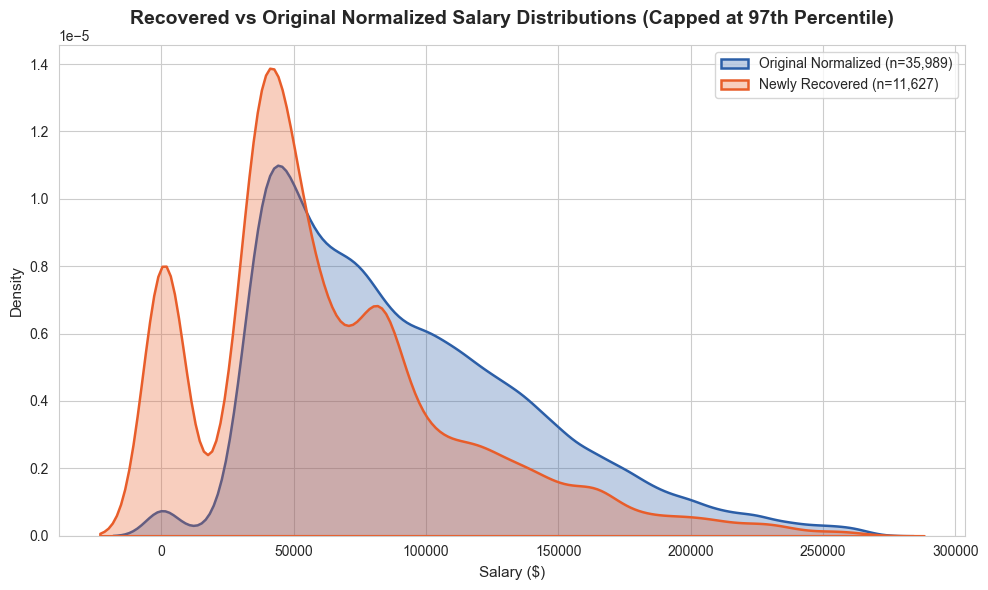

Newly Recovered Salaries: 11,627
Estimated Missing After Imputation: 75,929 (61.5%)


In [353]:
# Cap extracted salaries at the 99th percentile
valid_extracted = df_fe.loc[df_fe["extracted_salary"] > 0, "extracted_salary"]
if not valid_extracted.empty:
    percentile_97 = np.percentile(valid_extracted, 99)
    df_fe.loc[df_fe["extracted_salary"] > percentile_97, "extracted_salary"] = np.nan

# Identify newly recovered salaries
is_normalized_missing = df_fe["normalized_salary"].isna() | (df_fe["normalized_salary"] == 0)
is_extracted_present = df_fe["extracted_salary"].notna() & (df_fe["extracted_salary"] > 0)
newly_recovered_df = df_fe[is_normalized_missing & is_extracted_present].copy()

# --- Visualization ---

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

recovered_salaries = newly_recovered_df["extracted_salary"].dropna()
recovered_salaries = recovered_salaries[recovered_salaries > 0]

original_normalized = df_fe.loc[
    (df_fe["normalized_salary"].notna()) & (df_fe["normalized_salary"] > 0),
    "normalized_salary"
]

if not recovered_salaries.empty and not original_normalized.empty:
    combined_cap = np.percentile(
        np.concatenate([original_normalized.values, recovered_salaries.values]),
        97
    )
    norm_capped = original_normalized[original_normalized <= combined_cap]
    recov_capped = recovered_salaries[recovered_salaries <= combined_cap]

    sns.kdeplot(norm_capped, ax=ax, color="#2B5EA7", fill=True, alpha=0.3,
                linewidth=1.8, label=f"Original Normalized (n={len(original_normalized):,})")
    sns.kdeplot(recov_capped, ax=ax, color="#E85D2A", fill=True, alpha=0.3,
                linewidth=1.8, label=f"Newly Recovered (n={len(recovered_salaries):,})")

    ax.set_xlabel("Salary ($)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=10)

ax.set_title("Recovered vs Original Normalized Salary Distributions (Capped at 97th Percentile)",
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# --- Post-imputation missing stats ---
total_rows = len(df_fe)
newly_recovered_count = len(recovered_salaries)
missing_before = is_normalized_missing.sum()
missing_after = missing_before - newly_recovered_count
missing_pct_after = (missing_after / total_rows) * 100

print(f"Newly Recovered Salaries: {newly_recovered_count:,}")
print(f"Estimated Missing After Imputation: {missing_after:,} ({missing_pct_after:.1f}%)")

- **9,782 new salary values** recovered from unstructured text, but at least **77,774 (63.0%)** will still be missing after imputation
- Recovered salaries skew lower, clustering around **$30,000–$50,000** (likely from annualized hourly/daily rates)
- Visible spike near **$0** indicates false extractions (e.g., benefit descriptions, formatting artifacts) that need cleaning
- Plot is capped at the 97th percentile; upper-end outliers still exist in raw data and will be handled in later steps

### 4.2 Domain Extraction

Load pre-computed domain similarity scores from the external classification
script (`domain_probabilities.csv`). Each row contains cosine-similarity
scores between a job description and 13 industry-domain prototypes, produced
by a domain-aware BERT model
([`0xnbk/nbk-ats-domain-v1-en`](https://huggingface.co/0xnbk/nbk-ats-domain-v1-en)).

The highest-scoring domain is assigned as the label. If the best similarity
falls below `SIMILARITY_THRESHOLD` the posting receives the label `Unknown`.
The 14 resulting labels are one-hot encoded and the best similarity score is
kept as a continuous feature.

In [354]:
SIMILARITY_THRESHOLD = 0.35

# ---- Load pre-computed domain similarities ----
df_domains = pd.read_csv("../data/processed/domain_probabilities.csv")

# Similarity columns (everything except job_id)
sim_cols = [c for c in df_domains.columns if c.startswith("domain_sim_")]
domain_names = [c.replace("domain_sim_", "") for c in sim_cols]

# ---- Derive domain label + best score ----
sim_values = df_domains[sim_cols].values
best_idx = sim_values.argmax(axis=1)
best_score = sim_values[np.arange(len(sim_values)), best_idx]

df_domains["domain"] = np.where(
    best_score >= SIMILARITY_THRESHOLD,
    np.array(domain_names)[best_idx],
    "Unknown",
)
df_domains["domain_similarity"] = best_score

# ---- Merge into feature dataframe ----
df_fe = df_fe.merge(df_domains[["job_id", "domain", "domain_similarity"]], on="job_id", how="left")

# ---- One-hot encode domain labels ----
domain_dummies = pd.get_dummies(df_fe["domain"], prefix="domain")
df_fe = pd.concat([df_fe, domain_dummies], axis=1)

print(f"Domain columns added to df_fe  |  shape: {df_fe.shape}")
print(f"Unique domains assigned: {df_fe['domain'].nunique()}")

Domain columns added to df_fe  |  shape: (123545, 41)
Unique domains assigned: 14


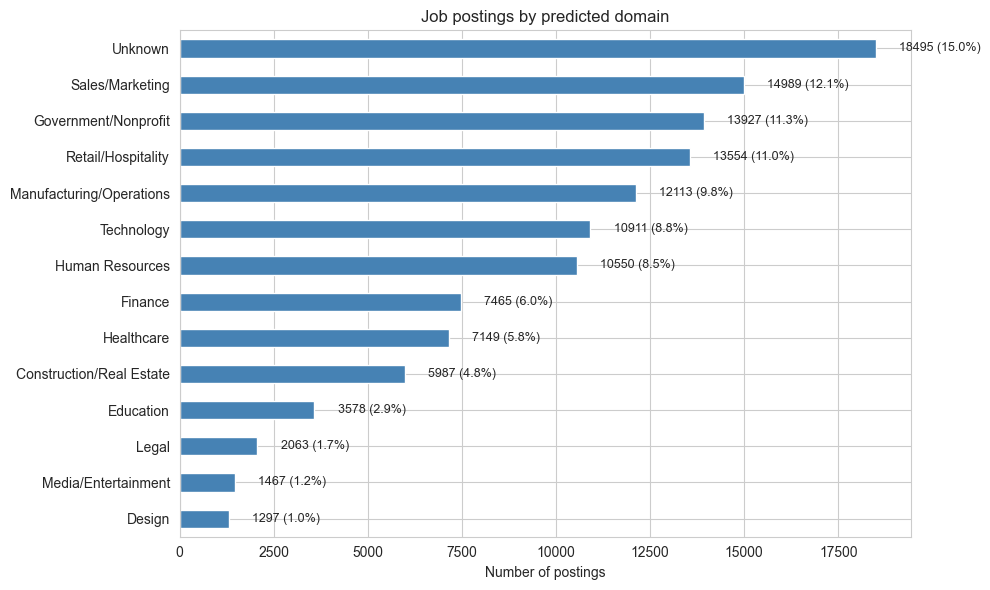

In [355]:
domain_cols = [
    "domain_Construction/Real Estate", "domain_Design", "domain_Education", 
    "domain_Finance", "domain_Government/Nonprofit", "domain_Healthcare", 
    "domain_Human Resources", "domain_Legal", "domain_Manufacturing/Operations", 
    "domain_Media/Entertainment", "domain_Retail/Hospitality", "domain_Sales/Marketing", 
    "domain_Technology", "domain_Unknown"
]

domain_counts = df_fe[domain_cols].sum()
domain_counts.index = domain_counts.index.str.replace("domain_", "")
domain_counts = domain_counts.sort_values()

total_count = domain_counts.sum()
percentages = (domain_counts / total_count * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = domain_counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")

for i, (domain, count) in enumerate(domain_counts.items()):
    pct = percentages[domain]
    ax.text(count + (total_count * 0.005), i, f'{int(count)} ({pct}%)', 
            va='center', fontsize=9)

ax.set_xlabel("Number of postings")
ax.set_title("Job postings by predicted domain")
plt.tight_layout()
plt.show()

**Observations:**

- The similarity threshold of **0.35** produces 14 domain classes (13 named + `Unknown`).
- `Unknown` has the highest count (~15%), likely capturing jobs that
  span multiple domains or do not fit neatly into any single one of the 13 defined categories.
- Top named domains are **Sales/Marketing**, **Government/Nonprofit**, and
  **Retail/Hospitality**, each exceeding 13,000 postings.
- Smaller domains like **Design**, **Media/Entertainment**, and **Legal** each
  hold fewer than 2,500 postings, reflecting their niche presence in the dataset.
- For the feature matrix the 14 domain labels will be **one-hot encoded**,
  and `domain_similarity` (confidence score) will be included as an additional
  continuous feature for downstream modelling.

### 4.3 Title-Based Experience Level Extraction

This subsection extracts seniority signals from job titles using targeted regex patterns to fill gaps in `experience_level_ord`. It scans titles top-down (Executive to Intern) so compound titles like *"Senior Director"* resolve to the highest applicable level. False-positive guards filter out misleading compounds where a seniority keyword loses its meaning (e.g., *"Executive Assistant"* is not executive-level, *"Senior Living Facility"* is not mid-senior).

In [356]:
TITLE_EXPERIENCE_PATTERNS = [
    # 0 - Internship
    (0, re.compile(r'\b(?:intern|internship)\b', re.IGNORECASE)),

    # 1 - Entry level
    (1, re.compile(r'\b(?:junior|jr\.?|entry[\s-]?level|trainee|apprentice)\b', re.IGNORECASE)),

    # 2 - Associate
    (2, re.compile(r'\b(?:associate)\b', re.IGNORECASE)),

    # 3 - Mid-Senior level
    (3, re.compile(r'\b(?:senior|sr\.?|staff|principal)\b', re.IGNORECASE)),

    # 4 - Director
    (4, re.compile(r'\b(?:director)\b', re.IGNORECASE)),

    # 5 - Executive
    (5, re.compile(
        r'\b(?:vice[\s-]?president|vp|c[eoftim]o|chief\s\w+\sofficer|president|partner)\b',
        re.IGNORECASE
    )),
]

# Titles where the seniority keyword loses its meaning
FALSE_POSITIVE_GUARDS = {
    5: re.compile(r'\b(?:executive\s+(?:assistant|secretary|coordinator|admin))\b', re.IGNORECASE),
    3: re.compile(r'\b(?:senior\s+(?:living|care|center|community|services))\b', re.IGNORECASE),
    2: re.compile(
        r'\b(?:'
        r'(?:sales|retail|warehouse|fulfillment|store|stock|team|pickup|delivery|deli)\s+associate'
        r'|associate\s+(?:dentist|veterinarian|pastor|broker)'
        r')\b',
        re.IGNORECASE
    ),
}


def extract_experience_from_title(title):
    """
    Returns an ordinal experience level (0-5) if an obvious keyword is found,
    otherwise returns None. Scans from highest seniority downward so that
    'Senior Director' maps to Director (4) rather than Mid-Senior (3),
    and 'Associate Director' maps to Director (4) rather than Associate (2).
    """
    if not isinstance(title, str) or not title.strip():
        return None

    # scan top-down (executive -> director -> senior -> associate -> entry -> intern)
    for level, pattern in reversed(TITLE_EXPERIENCE_PATTERNS):
        if pattern.search(title):
            guard = FALSE_POSITIVE_GUARDS.get(level)
            if guard and guard.search(title):
                continue
            return level

    return None

In [357]:
# ── Apply extraction to all rows ──

df_fe['title_experience_extracted'] = df_fe['title'].apply(extract_experience_from_title)

total = len(df_fe)
extracted_count = df_fe['title_experience_extracted'].notna().sum()

level_names = {0: 'Internship', 1: 'Entry', 2: 'Associate',
               3: 'Mid-Senior', 4: 'Director', 5: 'Executive'}

print(f"Total rows:              {total:,}")
print(f"Regex extracted value:   {extracted_count:,} ({extracted_count/total*100:.1f}%)")
print(f"No match (None):         {total - extracted_count:,} ({(total - extracted_count)/total*100:.1f}%)")
print("\nExtracted level distribution:")
for code, name in level_names.items():
    count = (df_fe['title_experience_extracted'] == code).sum()
    print(f"  {code} - {name}: {count:,}")

Total rows:              123,545
Regex extracted value:   24,132 (19.5%)
No match (None):         99,413 (80.5%)

Extracted level distribution:
  0 - Internship: 1,478
  1 - Entry: 1,720
  2 - Associate: 3,629
  3 - Mid-Senior: 11,456
  4 - Director: 4,147
  5 - Executive: 1,702


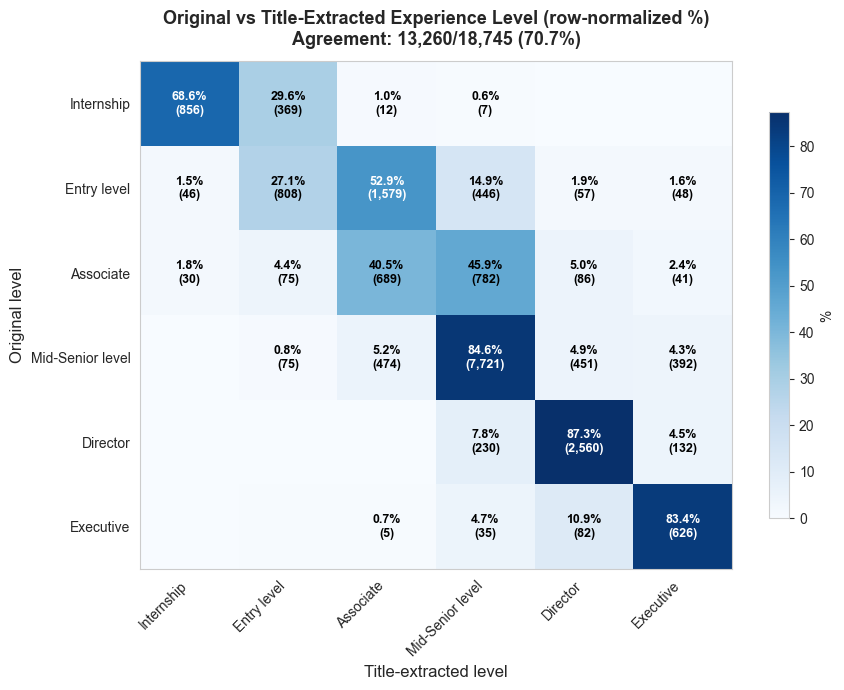

In [358]:
# ── Confusion heatmap: original (rows) vs extracted (cols) ──

level_names = {0: 'Internship', 1: 'Entry level', 2: 'Associate',
               3: 'Mid-Senior level', 4: 'Director', 5: 'Executive'}

# Map extracted codes to the same labels as formatted_experience_level
df_fe['title_experience_label'] = df_fe['title_experience_extracted'].map(level_names)

both_exist = df_fe['formatted_experience_level'].notna() & df_fe['title_experience_label'].notna()
df_both = df_fe.loc[both_exist, ['title', 'formatted_experience_level', 'title_experience_label']].copy()
df_both['match'] = df_both['formatted_experience_level'] == df_both['title_experience_label']

n_both = len(df_both)
n_match = df_both['match'].sum()

# Order labels by seniority for readable axes
label_order = ['Internship', 'Entry level', 'Associate',
               'Mid-Senior level', 'Director', 'Executive']

ct = pd.crosstab(
    df_both['formatted_experience_level'],
    df_both['title_experience_label'],
)
ct = ct.reindex(index=label_order, columns=label_order, fill_value=0)
ct_norm = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(ct_norm.values, cmap='Blues', aspect='auto')

ax.grid(False)
ax.set_xticks(range(len(ct_norm.columns)))
ax.set_yticks(range(len(ct_norm.index)))
ax.set_xticklabels(ct_norm.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ct_norm.index, fontsize=10)
ax.set_xlabel('Title-extracted level', fontsize=12)
ax.set_ylabel('Original level', fontsize=12)

for i in range(len(ct_norm.index)):
    for j in range(len(ct_norm.columns)):
        val = ct_norm.values[i, j]
        count = ct.values[i, j]
        if val > 0.5:
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{val:.1f}%\n({count:,})', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)

fig.colorbar(im, ax=ax, label='%', shrink=0.8)
ax.set_title(
    f'Original vs Title-Extracted Experience Level (row-normalized %)\n'
    f'Agreement: {n_match:,}/{n_both:,} ({n_match/n_both*100:.1f}%)',
    fontsize=13, fontweight='bold', pad=12
)
plt.tight_layout()
plt.show()

**Interpretation:** Overall agreement between original and regex-extracted levels is **70.7%**, with most disagreements occurring between adjacent levels (e.g., Entry↔Associate, Associate↔Mid-Senior). Senior levels show strong agreement (Mid-Senior 84.6%, Director 87.3%, Executive 83.4%). The regex extracted **5,387 new fills (4.4%)** for previously missing values. Given that errors are predominantly one-step mismatches and the fill volume is small, these new values are retained to reduce missingness in `experience_level_ord`.

In [359]:
# ── Fill missing formatted_experience_level with regex-extracted values ──

new_fills = df_fe['formatted_experience_level'].isna() & df_fe['title_experience_label'].notna()
fill_count = new_fills.sum()

df_fe['formatted_experience_level'] = df_fe['formatted_experience_level'].fillna(
    df_fe['title_experience_label']
)

# Clean up helper columns
df_fe.drop(columns=['title_experience_extracted', 'title_experience_label'], inplace=True)

remaining_nan = df_fe['formatted_experience_level'].isna().sum()
total = len(df_fe)
print(f"Filled {fill_count:,} missing values from title extraction")
print(f"Remaining NaN: {remaining_nan:,} ({remaining_nan/total*100:.1f}%)")

Filled 5,387 missing values from title extraction
Remaining NaN: 23,958 (19.4%)


### 4.4 Title and Description Length

Simple length-based features that capture posting verbosity. Longer descriptions often indicate more detailed or senior roles, while title word count reflects naming complexity.

In [360]:
# ── Title & description length features ──
df_fe['title_length']    = df_fe['title'].str.len()
df_fe['desc_word_count'] = df_fe['description'].fillna('').str.split().str.len()

df_fe[['title_length', 'desc_word_count']].describe().round(1)

,title_length,desc_word_count
count,123545.0,123545.0
mean,31.5,523.2
std,16.2,302.1
min,2.0,0.0
25%,20.0,298.0
50%,28.0,478.0
75%,39.0,696.0
max,200.0,3400.0


## 5. Numerical Features Engineering

### 5.1 Temporal Features and Posting Duration

The dataset spans roughly 15 days within a single month, which limits what temporal
features we can extract. Additionally, posting duration (`expiry - listed_time`) clusters
at exactly 30 days for ~96% of records, making it nearly constant as a continuous feature.

This section produces two features:
- `is_long_posting` - binary flag for the ~3% of postings with a 180-day window (vs the standard 30)
- `listed_day_of_week` - day of week the posting went live (0=Mon, 6=Sun)

> **Note on `listed_day_of_week`:** With only ~15 days of data, each weekday is backed by
> at most 3 calendar dates. Observed variation likely reflects date-specific volume rather
> than genuine weekly recruiter patterns. This feature is a candidate for removal during
> model training if feature importance confirms low predictive value.

In [361]:
# Convert epoch ms to datetime
df_fe['listed_dt'] = pd.to_datetime(df_fe['listed_time'], unit='ms', errors='coerce')
df_fe['expiry_dt'] = pd.to_datetime(df_fe['expiry'], unit='ms', errors='coerce')

# Posting duration in days
df_fe['posting_duration_days'] = (
    (df_fe['expiry_dt'] - df_fe['listed_dt']).dt.total_seconds() / 86400
).round(2)

# Confirm the dataset sits in a single month
print("Date range of listings:")
print(f"  Earliest: {df_fe['listed_dt'].min()}")
print(f"  Latest:   {df_fe['listed_dt'].max()}")
print(f"  Unique months: {df_fe['listed_dt'].dt.to_period('M').nunique()}")
month_counts = df_fe['listed_dt'].dt.to_period('M').value_counts().sort_index()
print("  Rows per month:")
for month, count in month_counts.items():
    print(f"    {month}: {count}")

Date range of listings:
  Earliest: 2024-03-24 21:50:14
  Latest:   2024-04-20 00:26:56
  Unique months: 2
  Rows per month:
    2024-03: 1
    2024-04: 123544


In [362]:
# ── Duration distribution: nearly all postings are exactly 30 or 180 days ──

# Define the ranges
range_30 = ((df_fe['posting_duration_days'] >= 29.5) & 
            (df_fe['posting_duration_days'] <= 30.5))

range_180 = ((df_fe['posting_duration_days'] >= 179.5) & 
             (df_fe['posting_duration_days'] <= 180))

others = ~(range_30 | range_180)

# Calculate percentages
pct_30 = range_30.mean() * 100
pct_180 = range_180.mean() * 100
pct_others = others.mean() * 100

print(f"Around 30 days (29.5-30.5):     {pct_30:6.2f}%  ({range_30.sum():,} records)")
print(f"Around 180 days (179.5-180):  {pct_180:6.2f}%  ({range_180.sum():,} records)")
print(f"Others:                      {pct_others:6.2f}%  ({others.sum():,} records)")
print(f"{'='*50}")
print(f"Total:                       {pct_30 + pct_180 + pct_others:6.2f}%  (123,545 records)")

Around 30 days (29.5-30.5):      96.19%  (118,840 records)
Around 180 days (179.5-180):    3.20%  (3,959 records)
Others:                        0.60%  (746 records)
Total:                       100.00%  (123,545 records)


With 96% of durations at exactly 30 days, `posting_duration_days` as a continuous feature offers
almost no variance. However, the ~3.2% minority at 180 days represents a meaningfully different
posting strategy (extended/evergreen listings), so we capture it as a binary flag.

In [363]:
# ── is_long_posting: flag for 180-day (extended) postings ──

df_fe['is_long_posting'] = (df_fe['posting_duration_days'] > 60).astype(int)

long_n = df_fe['is_long_posting'].sum()
total = len(df_fe)

print(f"is_long_posting distribution:")
print(f"  0 (standard ~30d): {total - long_n:,}  ({(total - long_n)/total*100:.1f}%)")
print(f"  1 (extended >60d): {long_n:,}  ({long_n/total*100:.1f}%)")

is_long_posting distribution:
  0 (standard ~30d): 119,528  (96.7%)
  1 (extended >60d): 4,017  (3.3%)


In [364]:
df_fe['listed_day_of_week'] = df_fe['listed_dt'].dt.dayofweek

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df_fe['listed_day_of_week'].value_counts().sort_index()

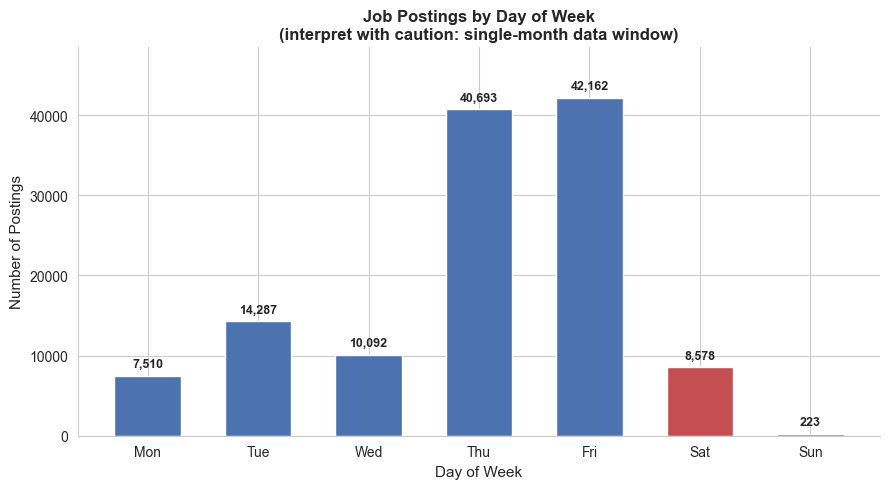


Calendar dates per weekday (confirms limited representation):

  Mon: 1 date(s) -> [datetime.date(2024, 4, 15)]
  Tue: 2 date(s) -> [datetime.date(2024, 4, 9), datetime.date(2024, 4, 16)]
  Wed: 1 date(s) -> [datetime.date(2024, 4, 17)]
  Thu: 2 date(s) -> [datetime.date(2024, 4, 11), datetime.date(2024, 4, 18)]
  Fri: 3 date(s) -> [datetime.date(2024, 4, 5), datetime.date(2024, 4, 12), datetime.date(2024, 4, 19)]
  Sat: 2 date(s) -> [datetime.date(2024, 4, 6), datetime.date(2024, 4, 20)]
  Sun: 2 date(s) -> [datetime.date(2024, 3, 24), datetime.date(2024, 4, 7)]


In [365]:
# ── listed_day_of_week (0=Mon, 6=Sun) ──

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4C72B0'] * 5 + ['#C44E52'] * 2
bars = ax.bar(dow_counts.index, dow_counts.values,
              color=colors, edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='{:,.0f}', fontsize=9, fontweight='bold', padding=4)

ax.set_xticks(range(7))
ax.set_xticklabels(dow_names, fontsize=10)
ax.set_xlabel('Day of Week', fontsize=11)
ax.set_ylabel('Number of Postings', fontsize=11)
ax.set_title('Job Postings by Day of Week\n(interpret with caution: single-month data window)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, dow_counts.max() * 1.15)
plt.tight_layout()
plt.show()

# Show which calendar dates back each weekday
print("\nCalendar dates per weekday (confirms limited representation):\n")
date_dow = df_fe[['listed_dt']].dropna().copy()
date_dow['date'] = date_dow['listed_dt'].dt.date
date_dow['dow'] = date_dow['listed_dt'].dt.dayofweek
for d in range(7):
    dates = sorted(date_dow[date_dow['dow'] == d]['date'].unique())
    print(f"  {dow_names[d]}: {len(dates)} date(s) -> {dates}")

### 5.2 Engagement Features

`views` and `applies` are heavily right-skewed count features. Log-transforming them
(via `log1p` to handle zeros) compresses the tail and improves linearity with other features.

We also derive `apply_rate = applies / views`, which captures how "converting" a posting is
independent of its raw exposure. Postings with zero views get `NaN` to avoid division artifacts.

This subsection produces three features:
- `log_views` - log(1 + views)
- `log_applies` - log(1 + applies)
- `apply_rate` - applies / views (NaN where views == 0)

In [366]:
# ── Engagement: log transforms + conversion rate ──

df_fe['log_views']   = np.log1p(df_fe['views'])
df_fe['log_applies'] = np.log1p(df_fe['applies'])

# Conversion rate: what fraction of viewers actually applied
df_fe['apply_rate'] = df_fe['applies'] / df_fe['views'].replace(0, np.nan)

print("Engagement feature summary:")
print(df_fe[['views', 'log_views', 'applies', 'log_applies', 'apply_rate']].describe().round(3))

Engagement feature summary:
            views   log_views    applies  log_applies  apply_rate
count  121856.000  121856.000  23320.000    23320.000   23319.000
mean       14.645       1.941     10.592        1.639       0.176
std        86.009       0.904     29.047        1.050       0.113
min         1.000       0.693      1.000        0.693       0.001
25%         3.000       1.386      1.000        0.693       0.091
50%         4.000       1.609      3.000        1.386       0.149
75%         8.000       2.197      8.000        2.197       0.235
max      9975.000       9.208    967.000        6.875       1.000


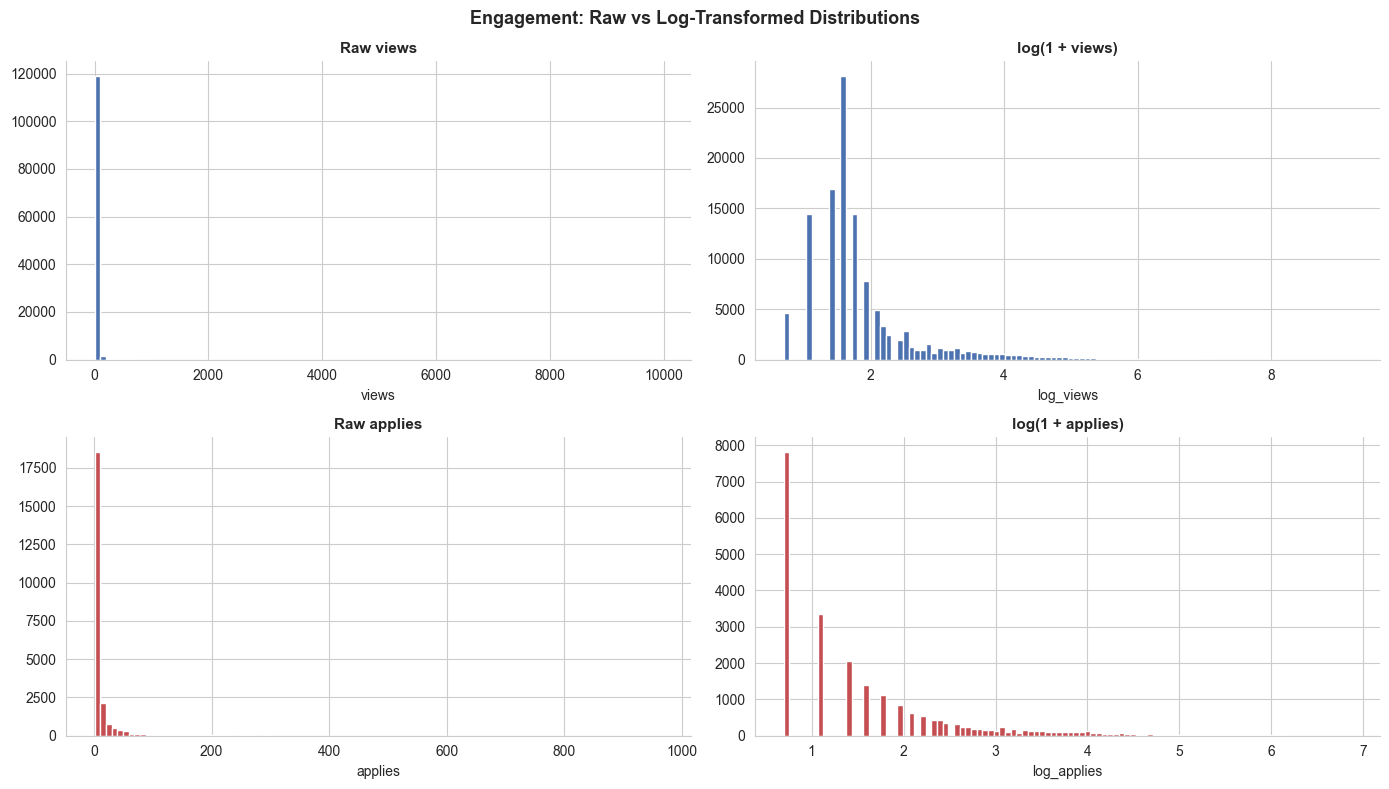

In [367]:
# ── Before vs after: raw vs log-transformed distributions ──

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw views
axes[0, 0].hist(df_fe['views'].dropna(), bins=100, color='#4C72B0', edgecolor='white')
axes[0, 0].set_title('Raw views', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('views')

# Log views
axes[0, 1].hist(df_fe['log_views'].dropna(), bins=100, color='#4C72B0', edgecolor='white')
axes[0, 1].set_title('log(1 + views)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('log_views')

# Raw applies
axes[1, 0].hist(df_fe['applies'].dropna(), bins=100, color='#C44E52', edgecolor='white')
axes[1, 0].set_title('Raw applies', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('applies')

# Log applies
axes[1, 1].hist(df_fe['log_applies'].dropna(), bins=100, color='#C44E52', edgecolor='white')
axes[1, 1].set_title('log(1 + applies)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('log_applies')

for ax in axes.flat:
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Engagement: Raw vs Log-Transformed Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

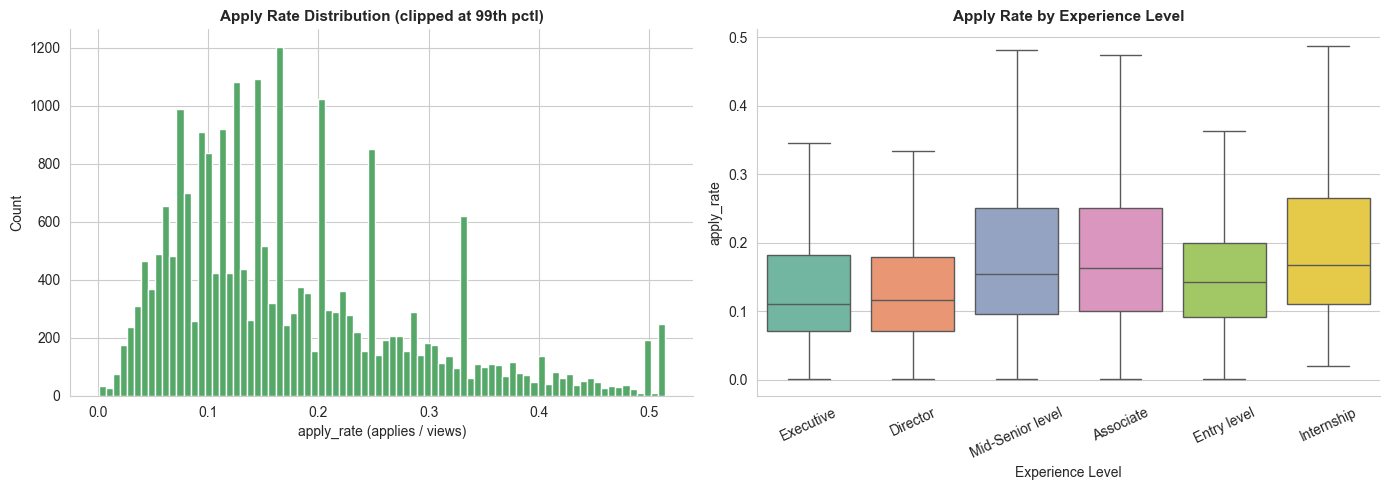

Median apply rate: 0.1486
Mean apply rate:   0.1765


In [368]:
# ── Apply rate distribution ──

valid_rate = df_fe['apply_rate'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(valid_rate.clip(upper=valid_rate.quantile(0.99)), bins=80,
             color='#55A868', edgecolor='white')
axes[0].set_title('Apply Rate Distribution (clipped at 99th pctl)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('apply_rate (applies / views)')
axes[0].set_ylabel('Count')
axes[0].spines[['top', 'right']].set_visible(False)

# Box plot by experience level
rate_by_exp = df_fe[['apply_rate', 'formatted_experience_level']].dropna()
if not rate_by_exp.empty:
    order = ['Executive', 'Director', 'Mid-Senior level',
             'Associate', 'Entry level', 'Internship']

    sns.boxplot(data=rate_by_exp, x='formatted_experience_level', y='apply_rate',
                order=order, hue='formatted_experience_level', hue_order=order,
                palette='Set2', ax=axes[1], showfliers=False, legend=False)
    axes[1].set_title('Apply Rate by Experience Level', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Experience Level')
    axes[1].set_ylabel('apply_rate')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Quick stats
print(f"Median apply rate: {valid_rate.median():.4f}")
print(f"Mean apply rate:   {valid_rate.mean():.4f}")

### 5.3 Salary Consolidation

Section 4.1 recovered ~9,800 salary values from description text via regex extraction.
Before merging them into `normalized_salary`, we need to clean the extracted values:

- **Floor at $10,000** to remove false positives
- **Cap at 98.5th percentile** to remove extreme outliers from mismatched pay-period conversions

After filtering, we fill missing `normalized_salary` entries with the cleaned extracted values.

In [369]:
# ── Filter extracted salaries: floor at $10K, cap at 98.5th percentile ──

raw_extracted = df_fe['extracted_salary'].dropna()
p985 = raw_extracted.quantile(0.96)

df_fe['extracted_salary_clean'] = df_fe['extracted_salary'].copy()
df_fe.loc[df_fe['extracted_salary_clean'] < 10_000, 'extracted_salary_clean'] = np.nan


df_fe.loc[df_fe['extracted_salary_clean'] > p985, 'extracted_salary_clean'] = np.nan

clean_extracted = df_fe['extracted_salary_clean'].dropna()

print(f"Extracted salary filtering:")
print(f"  Before filtering:  {len(raw_extracted):,} values")
print(f"  After filtering:   {len(clean_extracted):,} values")
print(f"  Removed:           {len(raw_extracted) - len(clean_extracted):,}")
print(f"  Floor:             $10,000")
print(f"  Cap (98.5th pctl): ${p985:,.0f}")

Extracted salary filtering:
  Before filtering:  29,468 values
  After filtering:   24,166 values
  Removed:           5,302
  Floor:             $10,000
  Cap (98.5th pctl): $252,916


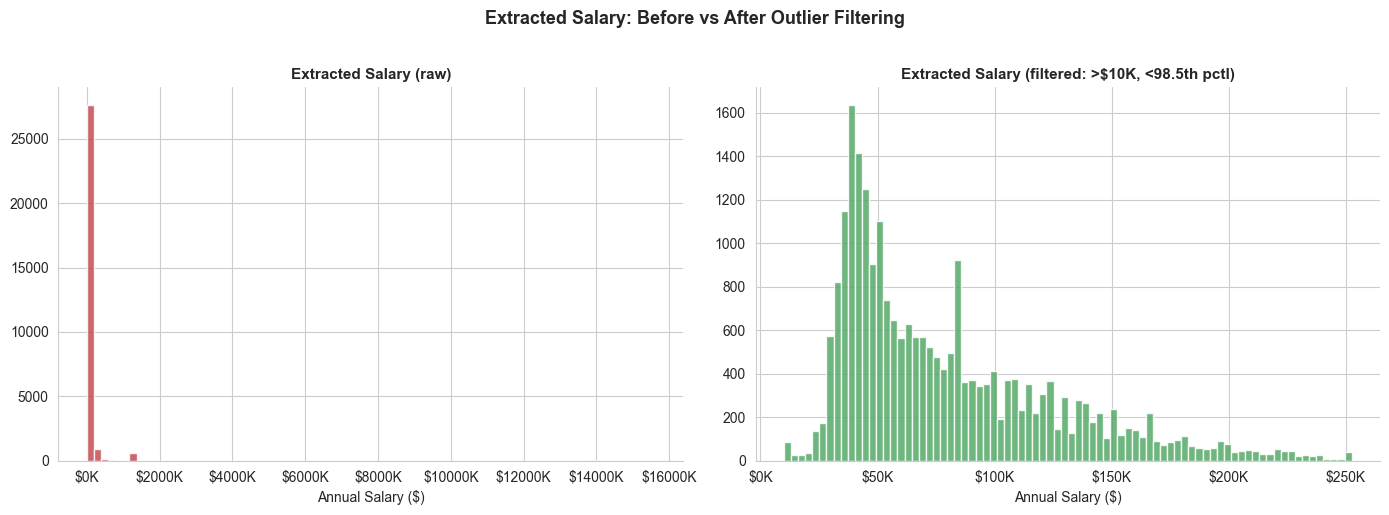

In [370]:
# ── Before vs after filtering: extracted salary distribution ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(raw_extracted, bins=80, color='#C44E52', edgecolor='white', alpha=0.85)
axes[0].set_title('Extracted Salary (raw)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Annual Salary ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(clean_extracted, bins=80, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].set_title('Extracted Salary (filtered: >$10K, <98.5th pctl)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Annual Salary ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Extracted Salary: Before vs After Outlier Filtering',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

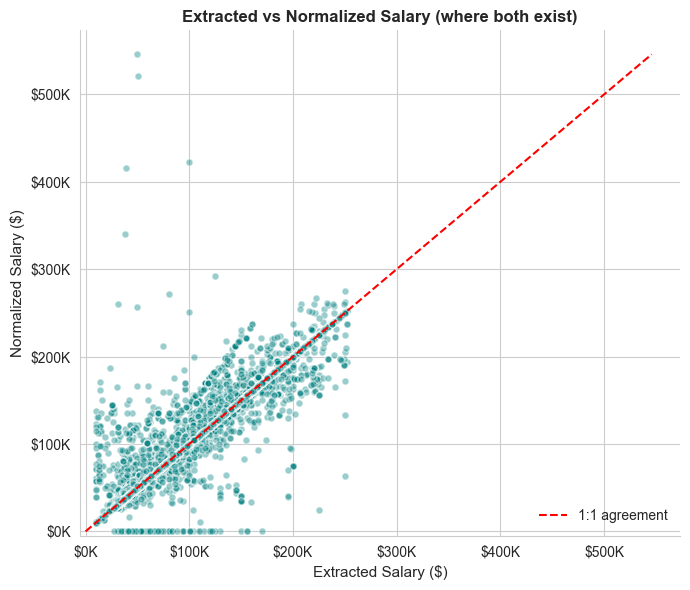

Pearson correlation where both exist: 0.938
Rows with both values: 15,135


In [371]:
# ── Alignment check: extracted vs normalized where both exist ──

both = df_fe[['normalized_salary', 'extracted_salary_clean']].dropna()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(both['extracted_salary_clean'], both['normalized_salary'],
           alpha=0.4, color='teal', edgecolor='w', s=25)

lims = [min(both.min()), max(both.max())]
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1.5, label='1:1 agreement')

# Add after the scatter, before plt.show()
ax.set_xlim(left=-5_000)
ax.set_ylim(bottom=-5_000)
ax.set_title('Extracted vs Normalized Salary (where both exist)', fontsize=12, fontweight='bold')
ax.set_xlabel('Extracted Salary ($)', fontsize=11)
ax.set_ylabel('Normalized Salary ($)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

r = both['normalized_salary'].corr(both['extracted_salary_clean'])
print(f"Pearson correlation where both exist: {r:.3f}")
print(f"Rows with both values: {len(both):,}")

In [372]:
# ── Merge: fill missing normalized_salary with cleaned extracted values ──

before_missing = df_fe['normalized_salary'].isna().sum()

df_fe['salary_source'] = np.where(
    df_fe['normalized_salary'].notna(), 'original',
    np.where(df_fe['extracted_salary_clean'].notna(), 'extracted', 'missing')
)

df_fe['normalized_salary'] = df_fe['normalized_salary'].fillna(df_fe['extracted_salary_clean'])

after_missing = df_fe['normalized_salary'].isna().sum()
filled = before_missing - after_missing

print("Salary consolidation results:")
print(f"  Missing before merge: {before_missing:,} ({before_missing/len(df_fe)*100:.1f}%)")
print(f"  Filled from text:     {filled:,}")
print(f"  Missing after merge:  {after_missing:,} ({after_missing/len(df_fe)*100:.1f}%)")
print(f"\nSource breakdown:")
print(df_fe['salary_source'].value_counts().to_string())

Salary consolidation results:
  Missing before merge: 87,542 (70.9%)
  Filled from text:     9,031
  Missing after merge:  78,511 (63.5%)

Source breakdown:
salary_source
missing      78511
original     36003
extracted     9031


**Observations:**

- Filtering removes false positives (sub-$10K noise) and extreme outliers from the extracted set.
- The scatter plot confirms reasonable agreement between extracted and normalized salaries where
  both exist, validating the regex extraction approach from 4.1.
- A significant portion of salary data remains missing and will be addressed in the
  imputation section after categorical encoding is complete.

## 6. Categorical Encoding (low cardinality)

Encoding strategy for low-cardinality categorical columns:

- `pay_period` - One-hot encoding (will be used in normalized salary calculation; missing values stay as all-zeros)
- `formatted_work_type` - One-hot encoding
- `application_type` - One-hot encoding
- `formatted_experience_level` - Ordinal encoding (natural hierarchy: Internship < Entry level < Associate < Mid-Senior level < Director < Executive)
- `currency` - Skipped here; used only in normalized salary calculation and removed in later steps
- `remote_allowed` - Binary encoding (87% missing; all observed values are 1/True, so NaN filled with 0/False before use)

### 6.1 One-Hot Encoding


In [373]:
ohe_columns = ['pay_period', 'formatted_work_type', 'application_type']

for col in ohe_columns:
    dummies = pd.get_dummies(df_fe[col], prefix=col, dtype=int)
    df_fe = pd.concat([df_fe, dummies], axis=1)
    df_fe.drop(columns=[col], inplace=True)

# Drop singleton OHE column (only 1 occurrence in entire dataset)
if 'application_type_UnknownApply' in df_fe.columns:
    if df_fe['application_type_UnknownApply'].sum() == 1:
        df_fe.drop(columns=['application_type_UnknownApply'], inplace=True)
        print("Dropped 'application_type_UnknownApply' (only 1 occurrence)")
    else:
        print(f"Kept 'application_type_UnknownApply' ({df_fe['application_type_UnknownApply'].sum()} occurrences)")

print(f"Columns after one-hot encoding: {df_fe.shape[1]}")
print("New OHE columns:")
for col in ohe_columns:
    ohe_cols = [c for c in df_fe.columns if c.startswith(col + '_')]
    print(f"  {col}: {ohe_cols}")

Dropped 'application_type_UnknownApply' (only 1 occurrence)
Columns after one-hot encoding: 65
New OHE columns:
  pay_period: ['pay_period_BIWEEKLY', 'pay_period_HOURLY', 'pay_period_MONTHLY', 'pay_period_WEEKLY', 'pay_period_YEARLY']
  formatted_work_type: ['formatted_work_type_Contract', 'formatted_work_type_Full-time', 'formatted_work_type_Internship', 'formatted_work_type_Other', 'formatted_work_type_Part-time', 'formatted_work_type_Temporary', 'formatted_work_type_Volunteer']
  application_type: ['application_type_ComplexOnsiteApply', 'application_type_OffsiteApply', 'application_type_SimpleOnsiteApply']


### 6.2 Ordinal Encoding: formatted_experience_level

In [374]:

experience_order = {
    'Internship':        0,
    'Entry level':       1,
    'Associate':         2,
    'Mid-Senior level':  3,
    'Director':          4,
    'Executive':         5
}

df_fe['experience_level_ord'] = df['formatted_experience_level'].map(experience_order)

print("Ordinal mapping applied:")
for level, code in experience_order.items():
    count = (df_fe['experience_level_ord'] == code).sum()
    print(f"  {code} = {level} ({count:,} rows)")

missing = df_fe['experience_level_ord'].isna().sum()
print(f"  NaN = missing ({missing:,} rows)")

df.drop(columns=['formatted_experience_level'], inplace=True)

Ordinal mapping applied:
  0 = Internship (1,441 rows)
  1 = Entry level (36,561 rows)
  2 = Associate (9,817 rows)
  3 = Mid-Senior level (41,413 rows)
  4 = Director (3,746 rows)
  5 = Executive (1,222 rows)
  NaN = missing (29,345 rows)


### 6.3 Binary Encoding

In [375]:
df_fe['remote_allowed'] = df_fe['remote_allowed'].fillna(0).astype(int)

print(f"remote_allowed distribution after fill:")
print(df_fe['remote_allowed'].value_counts())

remote_allowed distribution after fill:
remote_allowed
0    108306
1     15239
Name: count, dtype: int64


### Encoding summary

| Column | Method | Notes |
|--------|--------|-------|
| `pay_period` | One-hot | NaN rows get all-zero dummy columns; used in salary normalization |
| `formatted_work_type` | One-hot | No missing values |
| `application_type` | One-hot | No missing values; `UnknownApply` dummy dropped (single occurrence) |
| `formatted_experience_level` | Ordinal (0-5) | Natural rank order; NaN preserved for later imputation |
| `currency` | No encoding | Temporary helper for salary normalization; dropped later |
| `remote_allowed` | Binary (0/1) | ~87% NaN filled with 0 (False); all observed values were 1 (True) |

## 7. Train/Test Split

Before encoding high-cardinality features (Section 8), we need to split the data. Target encoding
and frequency encoding compute statistics from label/value distributions, so if the test set
contributes to those statistics, information leaks into the model and evaluation metrics
become unreliable.

**Steps in this section:**
1. Drop columns that are no longer needed (identifiers, raw text, intermediates, superseded originals)
2. Split into train/test (80/20)
3. Sanity-check that distributions look similar across both sets

### 7.1 Drop Redundant Columns

At this point several columns have been fully consumed by derived features and are no longer
needed as standalone columns. Keeping them around would add noise, waste memory, and risk
accidental use downstream.

| Category | Columns | Reason |
|----------|---------|--------|
| Identifiers | `job_id` | Not predictive |
| Raw text | `title`, `description` | Already used for domain, length, experience, salary extraction |
| Intermediate | `extracted_salary`, `extracted_salary_clean`, `salary_source`, `listed_dt`, `expiry_dt` | Temp columns from earlier sections |
| Superseded | `formatted_experience_level` | Replaced by `experience_level_ord` |
| Raw timestamps | `original_listed_time`, `listed_time`, `expiry` | Temporal features already derived (`posting_duration_days`, `is_long_posting`) |
| Raw salary components | `min_salary`, `max_salary`, `med_salary`, `currency` | Consolidated into `normalized_salary` |
| Raw engagement | `views`, `applies` | Superseded by `log_views`, `log_applies`, `apply_rate` |

Columns **kept for Section 8** (high-cardinality encoding):
`company_name`, `company_id`, `location`, `posting_domain`, `fips`, `zip_code`

In [376]:
# ── 7.1 Drop redundant columns ──

cols_to_drop = [
    # identifiers
    'job_id',

    # raw text (features already extracted)
    'title', 'description',

    # intermediate / temp columns
    'extracted_salary', 'extracted_salary_clean', 'salary_source',
    'listed_dt', 'expiry_dt', "posting_duration_days"

    # superseded by ordinal encoding
    'formatted_experience_level',

    # raw timestamps (temporal features derived)
    'original_listed_time', 'listed_time', 'expiry',

    # raw salary components (consolidated into normalized_salary)
    'min_salary', 'max_salary', 'med_salary', 'currency',

    # raw engagement (log versions kept)
    'views', 'applies',
]

# Only drop columns that actually exist (some may have been removed earlier)
existing_drops = [c for c in cols_to_drop if c in df_fe.columns]
skipped = [c for c in cols_to_drop if c not in df_fe.columns]

df_fe.drop(columns=existing_drops, inplace=True)

print(f"Dropped {len(existing_drops)} columns  |  Shape after: {df_fe.shape}")
if skipped:
    print(f"Already absent (skipped): {skipped}")

print(f"\nRemaining columns ({df_fe.shape[1]}):")
for i, col in enumerate(df_fe.columns):
    print(f"  {i+1:>2}. {col}")

Dropped 17 columns  |  Shape after: (123545, 49)
Already absent (skipped): ['posting_duration_daysformatted_experience_level']

Remaining columns (49):
   1. company_name
   2. location
   3. company_id
   4. remote_allowed
   5. formatted_experience_level
   6. posting_domain
   7. normalized_salary
   8. zip_code
   9. fips
  10. domain
  11. domain_similarity
  12. domain_Construction/Real Estate
  13. domain_Design
  14. domain_Education
  15. domain_Finance
  16. domain_Government/Nonprofit
  17. domain_Healthcare
  18. domain_Human Resources
  19. domain_Legal
  20. domain_Manufacturing/Operations
  21. domain_Media/Entertainment
  22. domain_Retail/Hospitality
  23. domain_Sales/Marketing
  24. domain_Technology
  25. domain_Unknown
  26. title_length
  27. desc_word_count
  28. posting_duration_days
  29. is_long_posting
  30. listed_day_of_week
  31. log_views
  32. log_applies
  33. apply_rate
  34. pay_period_BIWEEKLY
  35. pay_period_HOURLY
  36. pay_period_MONTHLY
  37. pa

### 7.2 Train/Test Split

80/20 random split with a fixed seed for reproducibility. Stratification is commented out
until the classification target is decided.


In [377]:
from sklearn.model_selection import train_test_split

# ── 7.2 Split ──

TEST_SIZE    = 0.20
RANDOM_STATE = 42
# TARGET_COL = '...' todo later without NaNs

train_idx, test_idx = train_test_split(
    df_fe.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    # stratify=df_fe[TARGET_COL], 
)

df_train = df_fe.loc[train_idx].copy()
df_test  = df_fe.loc[test_idx].copy()

print(f"Full dataset:  {len(df_fe):>7,} rows")
print(f"Training set:  {len(df_train):>7,} rows  ({len(df_train)/len(df_fe)*100:.1f}%)")
print(f"Test set:      {len(df_test):>7,} rows  ({len(df_test)/len(df_fe)*100:.1f}%)")

Full dataset:  123,545 rows
Training set:   98,836 rows  (80.0%)
Test set:       24,709 rows  (20.0%)


In [378]:
sanity_cols = [
    'normalized_salary', 'log_views', 'log_applies',
    'experience_level_ord', 'posting_duration_days', 'title_length',
]
available = [c for c in sanity_cols if c in df_train.columns]

comparison = pd.DataFrame({
    'train_mean':   df_train[available].mean(),
    'test_mean':    df_test[available].mean(),
    'train_median': df_train[available].median(),
    'test_median':  df_test[available].median(),
})
comparison['mean_pct_diff'] = (
    (comparison['test_mean'] - comparison['train_mean'])
    / comparison['train_mean'] * 100
).round(2)

print("Train vs Test distribution check:\n")
print(comparison.to_string())
print("\nAll differences < 2% confirms a balanced split.")

Train vs Test distribution check:

                         train_mean     test_mean  train_median   test_median  mean_pct_diff
normalized_salary      91579.394821  90823.479248  78000.000000  75928.500000          -0.83
log_views                  1.939737      1.943872      1.609438      1.609438           0.21
log_applies                1.641960      1.627263      1.386294      1.386294          -0.90
experience_level_ord       2.139825      2.137516      2.000000      2.000000          -0.11
posting_duration_days     34.874537     34.669615     30.000000     30.000000          -0.59
title_length              31.519254     31.515763     28.000000     28.000000          -0.01

All differences < 2% confirms a balanced split.


## 8. High-Cardinality Feature Engineering

Six columns remain with too many unique values for one-hot encoding:

| Column | Unique | Strategy |
|--------|--------|----------|
| `location` | 8.5K | decompose into `state`, then target-encode against salary |
| `fips` | 2.3K | target-encode against salary |
| `company_id` / `company_name` | 24K | frequency encoding |
| `posting_domain` | 4.4K | frequency encoding |

**Rules to prevent leakage:**
- Every encoder is **fit on `df_train` only**, then applied to both sets
- Target encoding uses `normalized_salary` as the target (NaN salaries are simply
  ignored during mean computation, not filled beforehand)
- Smoothing blends the category mean with the global mean, protecting against
  rare categories with only a few observations
  
**Missing value handling:**
- Target-encoded columns: NaN (from missing or unseen raw values) filled with the
  global salary mean in both train and test
- Frequency-encoded columns: NaN filled with 1 (minimal frequency) in both sets
- This way all four new columns exit this section with zero nulls

### 8.1 Location Decomposition + State Target Encoding

The `location` column is not a clean "City, ST" field. It contains a mix of formats:
- Standard: `"Princeton, NJ"`, `"Austin, TX"`
- Metro areas: `"Dallas-Fort Worth Metroplex"`, `"Greater Boston"`
- Broad labels: `"United States"`, `"NAMER"`
- International / unresolvable: `"Netherlands"`, `"Gambia"`, `"France"`

**Extraction strategy (three tiers):**
1. If the string contains a comma and the last piece is exactly 2 letters, treat it as
   a state abbreviation (covers the majority of rows)
2. Otherwise, match against a dictionary of regional keywords and major metro areas
   that map to known states (e.g. "Dallas-Fort Worth Metroplex" -> TX)
3. Broad US labels ("United States", "NAMER") get mapped to `"other"`; anything still
   unresolved is tagged `"noise"`

Rows tagged `"noise"` (~247) are mostly international postings that slipped through.
They are dropped from both sets rather than encoded, since they would pollute
the US-centric salary signal.

After extraction, states are target-encoded against `normalized_salary` with smoothing:

$$\text{encoded} = \frac{n_i \cdot \bar{y}_i + m \cdot \bar{y}_{global}}{n_i + m}$$

Where $n_i$ is the count of salary-known rows for that state, $\bar{y}_i$ is the state
mean salary, and $m$ is the smoothing factor. States with few observations get pulled
toward the global mean.

In [379]:
# ── 8.1a State extraction ──

# Regional keywords / metro areas that can't be parsed with a simple comma split
regional_patterns = {
    'ny': ['new york', 'buffalo-niagara falls area', 'utica-rome area'],
    'ca': ['san francisco', 'bay area', 'los angeles', 'sacramento',
           'san diego', 'silicon valley'],
    'tx': ['dallas', 'fort worth', 'houston', 'metroplex', 'texas', 'austin',
           'greater corpus christi area', 'san angelo area'],
    'dc': ['washington dc', 'baltimore'],
    'ga': ['atlanta', 'gainesville metropolitan area', 'greater macon'],
    'tn': ['nashville', 'memphis', 'knoxville metropolitan area'],
    'co': ['denver'],
    'ma': ['boston', 'greater boston',
           'springfield, massachusetts metropolitan area'],
    'fl': ['miami', 'fort lauderdale', 'orlando', 'metro jacksonville'],
    'az': ['phoenix'],
    'il': ['chicago', 'illinois', 'peoria metropolitan area'],
    'mn': ['minneapolis', 'st. paul', 'minnesota'],
    'mi': ['detroit', 'grand rapids', 'michigan'],
    'or': ['oregon', 'portland'],
    'ut': ['salt lake city', 'utah'],
    'wa': ['seattle', 'washington state'],
    'mo': ['kansas city', 'st. louis', 'missouri'],
    'ks': ['kansas metropolitan', 'topeka metropolitan area'],
    'in': ['indianapolis', 'indiana'],
    'nc': ['charlotte', 'greensboro', 'winston-salem', 'high point',
           'north carolina', 'raleigh-durham-chapel hill area'],
    'oh': ['cincinnati', 'cleveland', 'ohio'],
    'pa': ['pittsburgh', 'philadelphia', 'pennsylvania'],
    'ia': ['des moines', 'iowa'],
    'va': ['richmond', 'virginia'],
    'ar': ['little rock', 'arkansas'],
    'la': ['baton rouge', 'new orleans', 'louisiana'],
    'ct': ['hartford', 'connecticut'],
    'wi': ['appleton', 'oshkosh', 'neenah', 'eau claire', 'menomonie',
           'wisconsin', 'greater milwaukee', 'greater madison area'],
    'ne': ['omaha metropolitan area', 'lincoln, nebraska metropolitan area'],
    'nv': ['las vegas metropolitan area', 'greater reno area'],
    'sc': ['columbia, south carolina metropolitan area',
           'charleston, south carolina metropolitan area',
           'greenville-spartanburg-anderson, south carolina area'],
    'al': ['greater birmingham, alabama area',
           'huntsville-decatur-albertville area'],
    'ky': ['louisville metropolitan area'],
    'ok': ['oklahoma city metropolitan area'],
    'de': ['greater wilmington area'],
    'ak': ['greater anchorage area'],
    'id': ['boise metropolitan area', 'greater idaho falls'],
    'hi': ['maui', 'honolulu metropolitan area'],
    'nm': ['albuquerque-santa fe metropolitan area'],
}

def extract_state(loc):
    if pd.isna(loc):
        return np.nan

    loc_clean = str(loc).strip().lower()

    # tier 1: "City, ST" format (comma + 2-letter code)
    if ',' in loc_clean:
        last_part = loc_clean.split(',')[-1].strip()
        if len(last_part) == 2 and last_part.isalpha():
            return last_part

    # tier 2: broad US labels
    broad_terms = ['united states', 'namer']
    if any(term in loc_clean for term in broad_terms):
        return 'other'

    # tier 3: regional keyword matching
    for state, keywords in regional_patterns.items():
        if any(kw in loc_clean for kw in keywords):
            return state

    # unresolvable
    return 'noise'

df_train['state'] = df_train['location'].apply(extract_state)
df_test['state']  = df_test['location'].apply(extract_state)

# --- distribution check ---
print("State extraction results (train):\n")
state_counts = df_train['state'].value_counts()
print(f"  Resolved to a US state:  {state_counts.drop(['other', 'noise'], errors='ignore').sum():,}")
print(f"  Broad US ('other'):      {state_counts.get('other', 0):,}")
print(f"  Noise (unresolvable):    {state_counts.get('noise', 0):,}")
print(f"  NaN (missing location):  {df_train['state'].isna().sum():,}")

State extraction results (train):

  Resolved to a US state:  88,411
  Broad US ('other'):      10,178
  Noise (unresolvable):    247
  NaN (missing location):  0


In [380]:
# ── 8.1b Handle noise rows ──

noise_train = (df_train['state'] == 'noise').sum()
noise_test  = (df_test['state'] == 'noise').sum()

# drop from train (out-of-scope international postings)
df_train = df_train[df_train['state'] != 'noise'].copy()

# keep in test but remap to NaN so they get the global mean during encoding
df_test.loc[df_test['state'] == 'noise', 'state'] = np.nan

print(f"Train: dropped {noise_train} noise rows  ->  {len(df_train):,} remaining")
print(f"Test:  remapped {noise_test} noise rows to NaN (will receive global mean)")

Train: dropped 247 noise rows  ->  98,589 remaining
Test:  remapped 79 noise rows to NaN (will receive global mean)


In [381]:
# ── 8.1c State target encoding (fit on train only) ──

SMOOTHING = 20  # minimum sample weight

global_mean = df_train['normalized_salary'].mean()

state_stats = (
    df_train
    .groupby('state')['normalized_salary']
    .agg(['mean', 'count'])
)
state_stats['encoded'] = (
    (state_stats['count'] * state_stats['mean'] + SMOOTHING * global_mean)
    / (state_stats['count'] + SMOOTHING)
)
state_encoding = state_stats['encoded']

# apply to both sets
df_train['state_salary_enc'] = df_train['state'].map(state_encoding)
df_test['state_salary_enc']  = df_test['state'].map(state_encoding)

# missing / unseen states fall back to the global mean
train_missing_state = df_train['state_salary_enc'].isna().sum()
test_missing_state  = df_test['state_salary_enc'].isna().sum()

df_train['state_salary_enc'] = df_train['state_salary_enc'].fillna(global_mean)
df_test['state_salary_enc']  = df_test['state_salary_enc'].fillna(global_mean)

# --- summary ---
print(f"States encoded: {len(state_encoding)} (including 'other')")
print(f"Filled with global mean:  train={train_missing_state:,}  test={test_missing_state:,}")
print(f"Global salary mean: ${global_mean:,.0f}\n")

print("Top 5 highest-encoded states:")
print(state_stats.sort_values('encoded', ascending=False).head().to_string())
print("\nBottom 5:")
print(state_stats.sort_values('encoded', ascending=True).head().to_string())

# cleanup
df_train.drop(columns=['state', 'location'], inplace=True)
df_test.drop(columns=['state', 'location'], inplace=True)

States encoded: 54 (including 'other')
Filled with global mean:  train=2  test=79
Global salary mean: $91,597

Top 5 highest-encoded states:
                mean  count        encoded
state                                     
other  113908.517441   3976  113796.848153
dc     106658.204337    362  105869.659275
ny     102457.637900   3476  102395.506068
ca     102267.033793   6037  102231.801698
wa      98788.372915   1439   98689.793350

Bottom 5:
               mean  count       encoded
state                                   
ar     57548.600068    148  61601.980256
ok     62305.264459    185  65162.994137
ky     64432.340456    318  66039.716385
ia     65736.533009    226  67839.009484
ks     67551.073726    259  69274.795584


### 8.2 FIPS Target Encoding

FIPS codes identify counties, so they capture a finer geographic granularity than state.
Same smoothed target encoding approach, fit on train only.

`zip_code` is dropped rather than encoded because it overlaps heavily with `fips`
(both represent geography) and has more unique values (7K vs 2.3K). Encoding both would just produce two near-identical columns.

In [382]:
# ── 8.2 FIPS target encoding ──

fips_stats = (
    df_train
    .groupby('fips')['normalized_salary']
    .agg(['mean', 'count'])
)
fips_stats['encoded'] = (
    (fips_stats['count'] * fips_stats['mean'] + SMOOTHING * global_mean)
    / (fips_stats['count'] + SMOOTHING)
)
fips_encoding = fips_stats['encoded']

df_train['fips_salary_enc'] = df_train['fips'].map(fips_encoding)
df_test['fips_salary_enc']  = df_test['fips'].map(fips_encoding)

# missing / unseen FIPS fall back to the global mean
train_missing_fips = df_train['fips_salary_enc'].isna().sum()
test_missing_fips  = df_test['fips_salary_enc'].isna().sum()

df_train['fips_salary_enc'] = df_train['fips_salary_enc'].fillna(global_mean)
df_test['fips_salary_enc']  = df_test['fips_salary_enc'].fillna(global_mean)

# --- summary ---
print(f"Unique FIPS in train:  {fips_stats.shape[0]}")
print(f"Filled with global mean:  train={train_missing_fips:,}  test={test_missing_fips:,}")

print(f"\nEncoding range: ${fips_stats['encoded'].min():,.0f} - ${fips_stats['encoded'].max():,.0f}")
print(f"Median encoded value: ${fips_stats['encoded'].median():,.0f}")

# drop raw columns
df_train.drop(columns=['fips', 'zip_code'], inplace=True)
df_test.drop(columns=['fips', 'zip_code'], inplace=True)

Unique FIPS in train:  2181
Filled with global mean:  train=23,395  test=5,986

Encoding range: $64,276 - $147,053
Median encoded value: $88,751


### 8.3 Frequency Encoding (Company + Posting Domain)

Frequency encoding replaces each category with its count in the training set.
This captures "how active is this employer" and "how popular is this job board"
without leaking target information.

- `company_id` frequency encodes employer activity level
- `posting_domain` frequency encodes platform volume
- `company_name` is dropped (text duplicate of `company_id`)

In [383]:
# ── 8.3 Frequency encoding ──

freq_configs = {
    'company_id':     'company_freq',
    'posting_domain': 'posting_domain_freq',
}

for raw_col, new_col in freq_configs.items():
    # fit on train
    freq_map = df_train[raw_col].value_counts()

    # apply to both
    df_train[new_col] = df_train[raw_col].map(freq_map)
    df_test[new_col]  = df_test[raw_col].map(freq_map)

    # unseen categories in test get 1 (appeared once, conservative default)
    unseen_mask = df_test[new_col].isna() & df_test[raw_col].notna()
    df_test.loc[unseen_mask, new_col] = 1

    # missing raw values (NaN company_id / posting_domain) get filled with 1 in both sets
    train_missing = df_train[new_col].isna().sum()
    test_missing  = df_test[new_col].isna().sum()

    df_train[new_col] = df_train[new_col].fillna(1)
    df_test[new_col]  = df_test[new_col].fillna(1)

    unseen_count = unseen_mask.sum()
    print(f"{raw_col} -> {new_col}")
    print(f"  Unique in train: {freq_map.shape[0]:,}")
    print(f"  Test rows with unseen value (set to 1): {unseen_count}")
    print(f"  NaN raw values filled with 1:  train={train_missing:,}  test={test_missing:,}")
    print(f"  Range: {freq_map.min()} - {freq_map.max()}")
    print()

# drop raw columns
df_train.drop(columns=['company_id', 'company_name', 'posting_domain'], inplace=True)
df_test.drop(columns=['company_id', 'company_name', 'posting_domain'], inplace=True)

company_id -> company_freq
  Unique in train: 21,349
  Test rows with unseen value (set to 1): 3240
  NaN raw values filled with 1:  train=1,367  test=341
  Range: 1 - 911

posting_domain -> posting_domain_freq
  Unique in train: 4,159
  Test rows with unseen value (set to 1): 297
  NaN raw values filled with 1:  train=31,858  test=7,989
  Range: 1 - 3055



### Section 8 Summary

| Original Column | Method | New Column | Dropped |
|-----------------|--------|------------|---------|
| `location` | state extraction (3-tier) + target encoding | `state_salary_enc` | `location`, `state`, ~247 noise rows |
| `fips` | target encoding (smoothed) | `fips_salary_enc` | `fips`, `zip_code` |
| `company_id` | frequency encoding | `company_freq` | `company_id`, `company_name` |
| `posting_domain` | frequency encoding | `posting_domain_freq` | `posting_domain` |


## 9. Export Feature Matrix

All feature engineering steps are complete. This section documents the final feature set
and exports the train/test splits as the modeling-ready feature matrix.

**Note:** Missing value imputation and feature scaling are intentionally deferred to the
modeling phase, where the strategy will depend on the specific model and task.

### 9.1 Final Feature Overview

In [384]:
# ── Final column inventory ──

print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print(f"Columns ({df_train.shape[1]}):")

for i, (col, dtype) in enumerate(df_train.dtypes.items(), 1):
    n_unique = df_train[col].nunique()
    missing  = df_train[col].isna().sum()
    pct_miss = missing / len(df_train) * 100
    miss_str = f"  [{missing:,} missing, {pct_miss:.1f}%]" if missing > 0 else ""
    print(f"  {i:>2}. {col:<35} {str(dtype):<10}  unique={n_unique:<8,}{miss_str}")

Train shape: (98589, 47)
Test shape:  (24709, 47)
Columns (47):
   1. remote_allowed                      int64       unique=2       
   2. formatted_experience_level          str         unique=6         [19,149 missing, 19.4%]
   3. normalized_salary                   float64     unique=7,149     [62,570 missing, 63.5%]
   4. domain                              str         unique=14      
   5. domain_similarity                   float64     unique=7,666   
   6. domain_Construction/Real Estate     bool        unique=2       
   7. domain_Design                       bool        unique=2       
   8. domain_Education                    bool        unique=2       
   9. domain_Finance                      bool        unique=2       
  10. domain_Government/Nonprofit         bool        unique=2       
  11. domain_Healthcare                   bool        unique=2       
  12. domain_Human Resources              bool        unique=2       
  13. domain_Legal                        bool

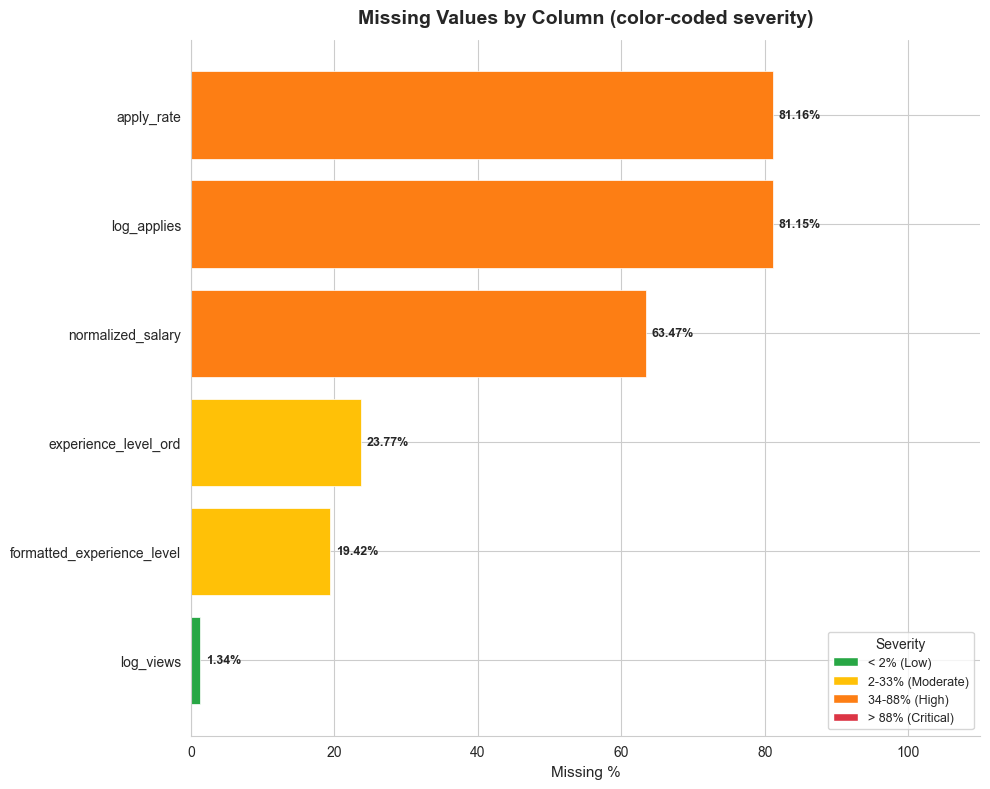

In [385]:
missing_pct = (df_train.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]  # only columns with missing values

def severity_color(pct):
    if pct < 2:
        return '#28a745'   # green
    elif pct < 33:
        return '#ffc107'   # yellow
    elif pct < 88:
        return '#fd7e14'   # orange
    else:
        return '#dc3545'   # red

colors = [severity_color(p) for p in missing_pct.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

legend_items = [
    Patch(facecolor='#28a745', label='< 2% (Low)'),
    Patch(facecolor='#ffc107', label='2-33% (Moderate)'),
    Patch(facecolor='#fd7e14', label='34-88% (High)'),
    Patch(facecolor='#dc3545', label='> 88% (Critical)')
]
ax.legend(handles=legend_items, loc='lower right', fontsize=9, title='Severity', title_fontsize=10)

ax.set_xlabel('Missing %', fontsize=11)
ax.set_title('Missing Values by Column (color-coded severity)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

 9.2 Feature Grouping

 For reference, features fall into these logical groups:

 | Group | Features | Source |
 |-------|----------|--------|
 | **Salary** | `normalized_salary` | Cleaned + text-extracted (Sec 4.1, 5.3) |
 | **Text-derived** | `title_length`, `desc_word_count` | Title/description length (Sec 4.4) |
 | **Domain similarity** | `domain_*` columns (14 total) | Cosine similarity scores (Sec 4.2) |
 | **Temporal** | `posting_duration_days`, `is_long_posting`, `listed_day_of_week` | Epoch timestamps (Sec 5.1) |
 | **Engagement** | `log_views`, `log_applies`, `apply_rate` | Log-transformed counts + ratio (Sec 5.2) |
 | **Categorical (OHE)** | `pay_period_*`, `formatted_work_type_*`, `application_type_*` | One-hot encoded (Sec 6.1) |
 | **Ordinal** | `experience_level_ord` | Experience level mapping (Sec 6.2) |
 | **Binary** | `remote_allowed` | Binary fill (Sec 6.3) |
 | **Target-encoded** | `state_salary_enc`, `fips_salary_enc` | Smoothed target encoding (Sec 8.1, 8.2) |
 | **Frequency-encoded** | `company_freq`, `posting_domain_freq` | Train-set frequency counts (Sec 8.3) |
 


### 9.3 Export

In [386]:
# ── Save feature matrices ──

import os

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

train_path = os.path.join(output_dir, "feature_matrix_train.csv")
test_path  = os.path.join(output_dir, "feature_matrix_test.csv")

df_train.to_csv(train_path, index=False)
df_test.to_csv(test_path, index=False)

print(f"Train exported: {train_path}  ({df_train.shape[0]:,} rows x {df_train.shape[1]} cols)")
print(f"Test exported:  {test_path}  ({df_test.shape[0]:,} rows x {df_test.shape[1]} cols)")

Train exported: ../data/processed\feature_matrix_train.csv  (98,589 rows x 47 cols)
Test exported:  ../data/processed\feature_matrix_test.csv  (24,709 rows x 47 cols)


In [387]:
# ── Verify export integrity ──

df_train_check = pd.read_csv(train_path)
df_test_check  = pd.read_csv(test_path)

assert df_train_check.shape == df_train.shape, "Train shape mismatch after reload!"
assert df_test_check.shape  == df_test.shape,  "Test shape mismatch after reload!"
assert list(df_train_check.columns) == list(df_train.columns), "Train columns mismatch!"
assert list(df_test_check.columns)  == list(df_test.columns),  "Test columns mismatch!"

print("Export verification passed:")
print(f"  Train: {df_train_check.shape}")
print(f"  Test:  {df_test_check.shape}")

Export verification passed:
  Train: (98589, 47)
  Test:  (24709, 47)


### 9.4 Summary

The feature matrix is exported and ready for modeling. Key points:

- **No imputation applied yet.** Columns like  (~37% missing) and
   (~32% missing) still contain NaNs. Imputation strategy will be
  chosen per-model (e.g., median fill for linear models, native NaN handling for tree-based).
- **No scaling applied yet.** Features like  (range 1 to ~1K+) and 
  (range 0 to ~12) live on different scales. Standardization or min-max scaling will be
  applied in the training pipeline where needed.
- **Target encoding was fit on train only.** Test set values were mapped from the
  train-fitted lookup, with unseen categories falling back to the global mean.
- **Train/test split is preserved.** Both files can be loaded independently for modeling
  without risk of data leakage.